# Stage 1 – Anomali Tespiti: Isolation Forest

**Amaç:** XGBoost risk modelinden önce, veri setindeki aykırı/anormal başvuruları tespit et ve filtrele.  
**Model:** `IsolationForest` (scikit-learn)  
**Parametre kaynağı:** `configs/model_params.yaml`

Pipeline'daki yeri:
```
Ham Başvuru → [Stage 1: Anomali Tespiti] → Temiz Başvuru → [Stage 2: Risk Skoru] → [Stage 3: Faiz]
```

> **Not (Fit Context):** Model **sadece eğitim seti (`X_train`)** üzerinde eğitilmiştir (fit). Data leakage'ı önlemek adına test seti modele gösterilmemiş, sadece `predict` aşamasında kullanılmıştır.

## 1. Kütüphaneler ve Sabitler

In [1]:
import json
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

ROOT = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed'
MODEL_DIR  = ROOT / 'models'
FIG_DIR    = ROOT / 'reports' / 'figures'
METRIC_DIR = ROOT / 'reports' / 'metrics'
CONFIG_PATH = ROOT / 'configs' / 'model_params.yaml'

print('ROOT:', ROOT)
print('DATA_DIR:', DATA_DIR)

ROOT: C:\Users\nesli\Desktop\LoanGuard
DATA_DIR: C:\Users\nesli\Desktop\LoanGuard\data\processed


## 2. Konfigürasyon

In [2]:
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

params = cfg['anomaly_detection']['params']
print('Isolation Forest parametreleri:')
for k, v in params.items():
    print(f'  {k}: {v}')

Isolation Forest parametreleri:
  n_estimators: 100
  contamination: 0.05
  random_state: 42
  n_jobs: -1


## 3. Veri Yükleme

In [3]:
X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
X_test  = pd.read_csv(DATA_DIR / 'X_test.csv')
y_test  = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Default oranı (train): {y_train.mean():.3f}')

Train: (204277, 20), Test: (51070, 20)
Default oranı (train): 0.116


## 4. Isolation Forest Eğitimi

Isolation Forest denetimsiz öğrenmedir — sadece X ile eğitilir, etiket görmez.  
`contamination=0.05` → verinin %5'ini anomali olarak işaretleyeceğimizi bekliyor.

In [4]:
iso = IsolationForest(**params)
iso.fit(X_train)
print('Eğitim tamamlandı.')

Eğitim tamamlandı.


## 5. Anomali Skorları

In [5]:
# score_samples: yüksek = normal, düşük = anomali
train_scores = iso.score_samples(X_train)
test_scores  = iso.score_samples(X_test)

# predict: -1 = anomali, 1 = normal
train_preds = iso.predict(X_train)  # -1 veya 1
test_preds  = iso.predict(X_test)

# İkili flag: 1 = anomali, 0 = normal
train_anomaly = (train_preds == -1).astype(int)
test_anomaly  = (test_preds == -1).astype(int)

print(f'Train anomali sayısı: {train_anomaly.sum()} ({train_anomaly.mean()*100:.1f}%)')
print(f'Test  anomali sayısı: {test_anomaly.sum()} ({test_anomaly.mean()*100:.1f}%)')

Train anomali sayısı: 10214 (5.0%)
Test  anomali sayısı: 2576 (5.0%)


## 6. Görselleştirme

### 6.1 Anomali Skoru Dağılımı

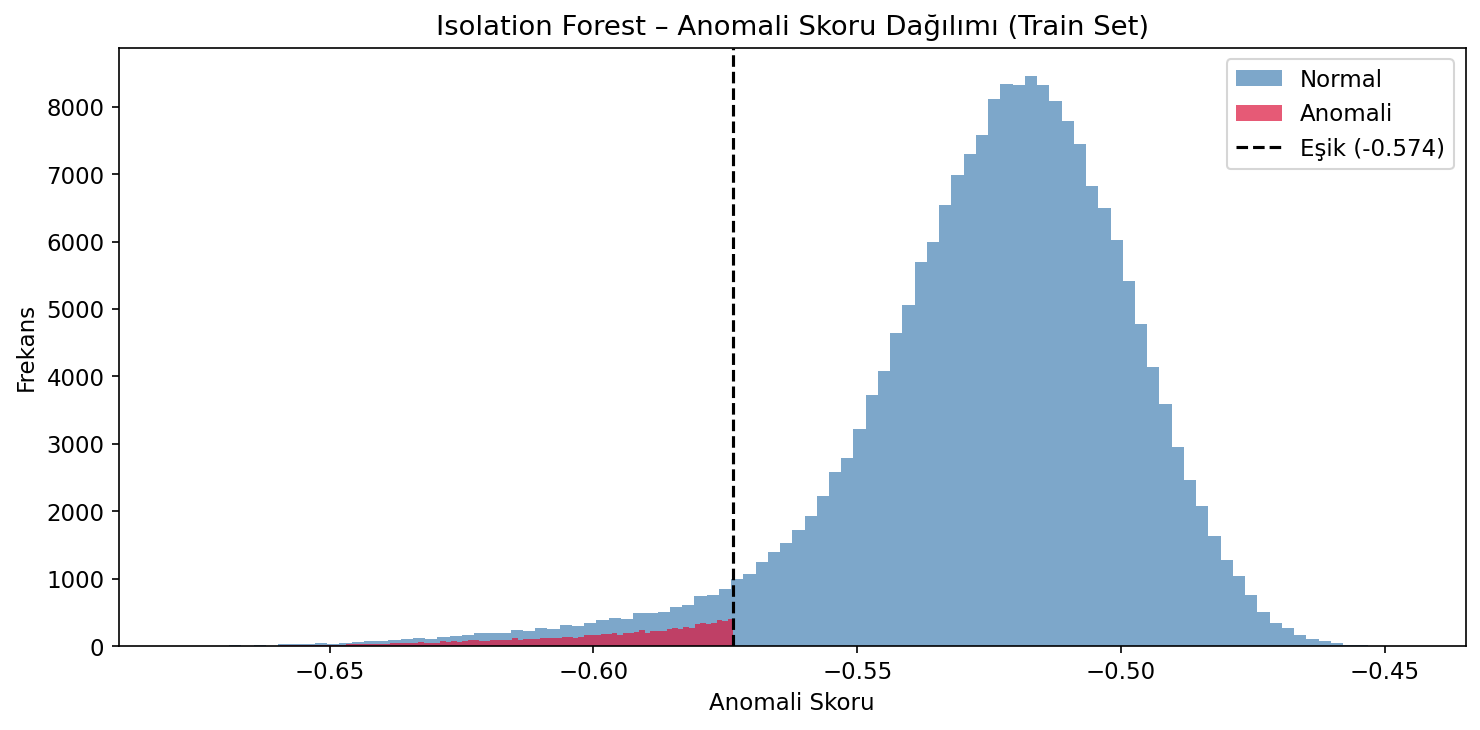

Kaydedildi: if_01_anomaly_score_distribution.png


In [6]:
threshold_val = np.percentile(train_scores, 5)  # contamination=0.05

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_scores, bins=100, color='steelblue', alpha=0.7, label='Normal')
ax.hist(train_scores[train_anomaly == 1], bins=100, color='crimson', alpha=0.7, label='Anomali')
ax.axvline(threshold_val, color='black', linestyle='--', linewidth=1.5,
           label=f'Eşik ({threshold_val:.3f})')
ax.set_xlabel('Anomali Skoru')
ax.set_ylabel('Frekans')
ax.set_title('Isolation Forest – Anomali Skoru Dağılımı (Train Set)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'if_01_anomaly_score_distribution.png')
plt.show()
print('Kaydedildi: if_01_anomaly_score_distribution.png')

### 6.2 Anomali vs. Default Örtüşmesi

In [7]:
# Anomali ve Default etiketlerini birleştir
analysis = pd.DataFrame({
    'anomaly': train_anomaly,
    'default': y_train.values,
    'score': train_scores
})

# 2x2 tablo
cross = pd.crosstab(
    analysis['anomaly'].map({0: 'Normal', 1: 'Anomali'}),
    analysis['default'].map({0: 'Ödendi', 1: 'Default'}),
    margins=True
)
print('Çapraz tablo:')
print(cross)

# Anomali içindeki default oranı
anomaly_df = analysis[analysis['anomaly'] == 1]
normal_df  = analysis[analysis['anomaly'] == 0]
print(f'\nAnomali grubunda default oranı: {anomaly_df["default"].mean()*100:.1f}%')
print(f'Normal grubunda default oranı:  {normal_df["default"].mean()*100:.1f}%')

Çapraz tablo:
default  Default  Ödendi     All
anomaly                         
Anomali     3118    7096   10214
Normal     20604  173459  194063
All        23722  180555  204277

Anomali grubunda default oranı: 30.5%
Normal grubunda default oranı:  10.6%


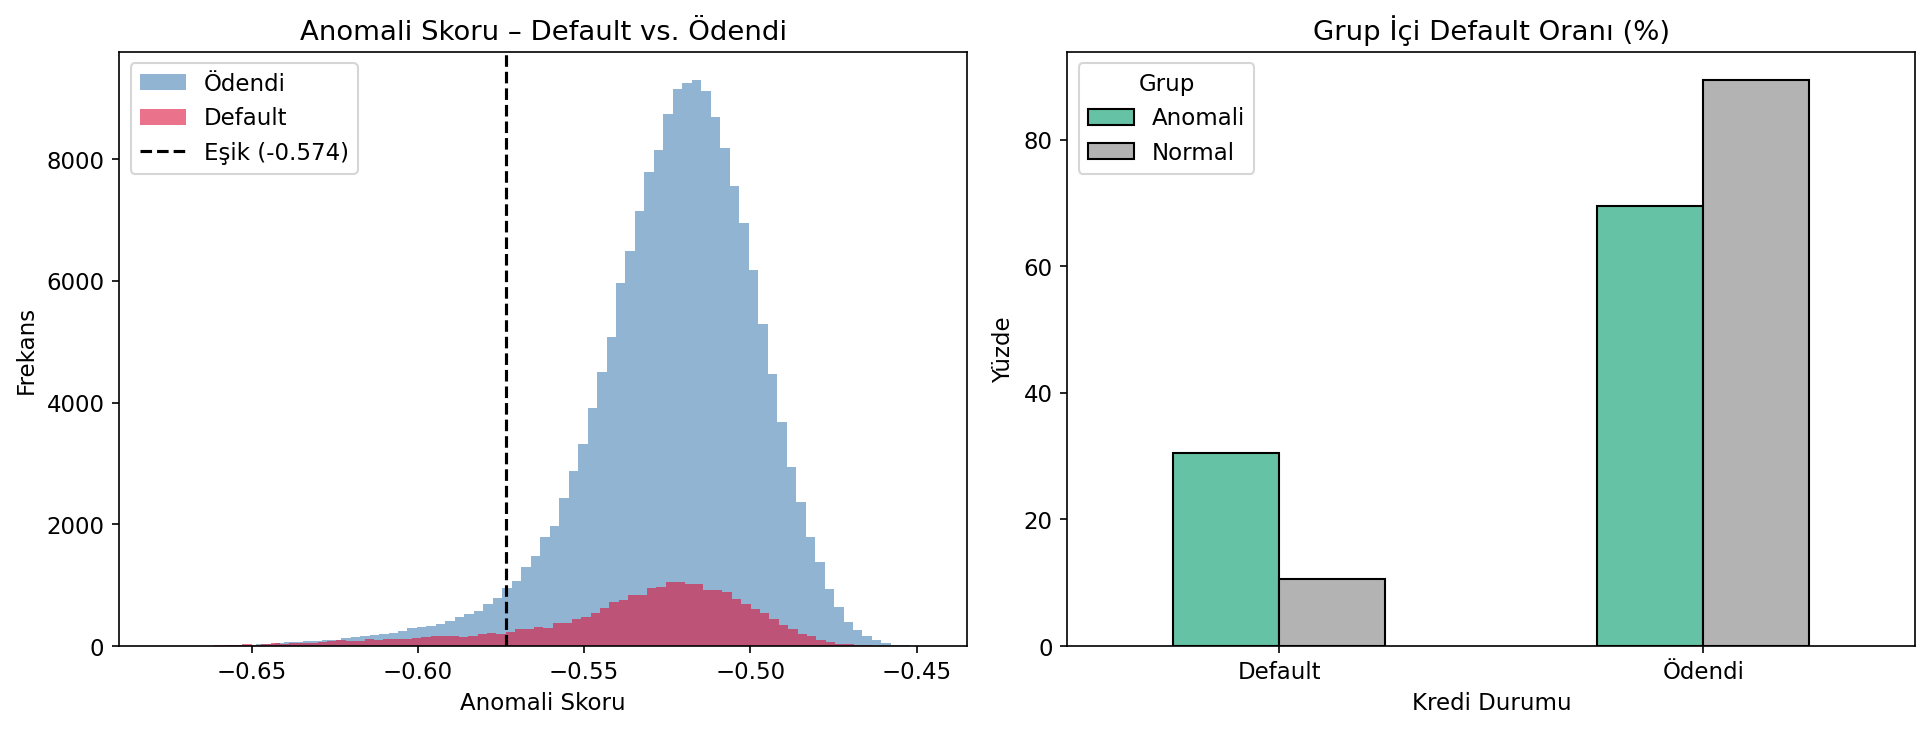

Kaydedildi: if_02_anomaly_vs_default_overlap.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sol: Skor dağılımı default vs ödendi
for label, color, name in [(0, 'steelblue', 'Ödendi'), (1, 'crimson', 'Default')]:
    axes[0].hist(analysis.loc[analysis['default'] == label, 'score'],
                 bins=80, alpha=0.6, color=color, label=name)
axes[0].axvline(threshold_val, color='black', linestyle='--', linewidth=1.5,
                label=f'Eşik ({threshold_val:.3f})')
axes[0].set_title('Anomali Skoru – Default vs. Ödendi')
axes[0].set_xlabel('Anomali Skoru')
axes[0].set_ylabel('Frekans')
axes[0].legend()

# Sağ: Anomali grubunun default dağılımı (pasta)
cross_pct = pd.crosstab(
    analysis['anomaly'].map({0: 'Normal', 1: 'Anomali'}),
    analysis['default'].map({0: 'Ödendi', 1: 'Default'}),
    normalize='index'
) * 100
cross_pct.T.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_title('Grup İçi Default Oranı (%)')
axes[1].set_xlabel('Kredi Durumu')
axes[1].set_ylabel('Yüzde')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Grup')

plt.tight_layout()
plt.savefig(FIG_DIR / 'if_02_anomaly_vs_default_overlap.png')
plt.show()
print('Kaydedildi: if_02_anomaly_vs_default_overlap.png')

### 6.3 Pipeline Karşılaştırması: Anomali Filtresiyle vs. Filtresiz

In [9]:
# XGBoost metriklerini yükle (karşılaştırma için)
with open(METRIC_DIR / 'xgboost_metrics.json') as f:
    xgb_metrics = json.load(f)

# Anomali filtreli test seti
clean_mask = test_anomaly == 0
n_total    = len(test_anomaly)
n_clean    = clean_mask.sum()
n_anomaly  = (~clean_mask).sum()

print(f'Test seti: {n_total} başvuru')
print(f'  Temiz  : {n_clean} ({n_clean/n_total*100:.1f}%)')
print(f'  Anomali: {n_anomaly} ({n_anomaly/n_total*100:.1f}%)')

# Anomali grubundaki default oranı vs temiz grup
default_rate_clean   = y_test[clean_mask].mean()
default_rate_anomaly = y_test[~clean_mask].mean()
print(f'\nTemiz grupta default oranı   : {default_rate_clean*100:.1f}%')
print(f'Anomali grubunda default oranı: {default_rate_anomaly*100:.1f}%')

Test seti: 51070 başvuru
  Temiz  : 48494 (95.0%)
  Anomali: 2576 (5.0%)

Temiz grupta default oranı   : 10.6%
Anomali grubunda default oranı: 31.2%


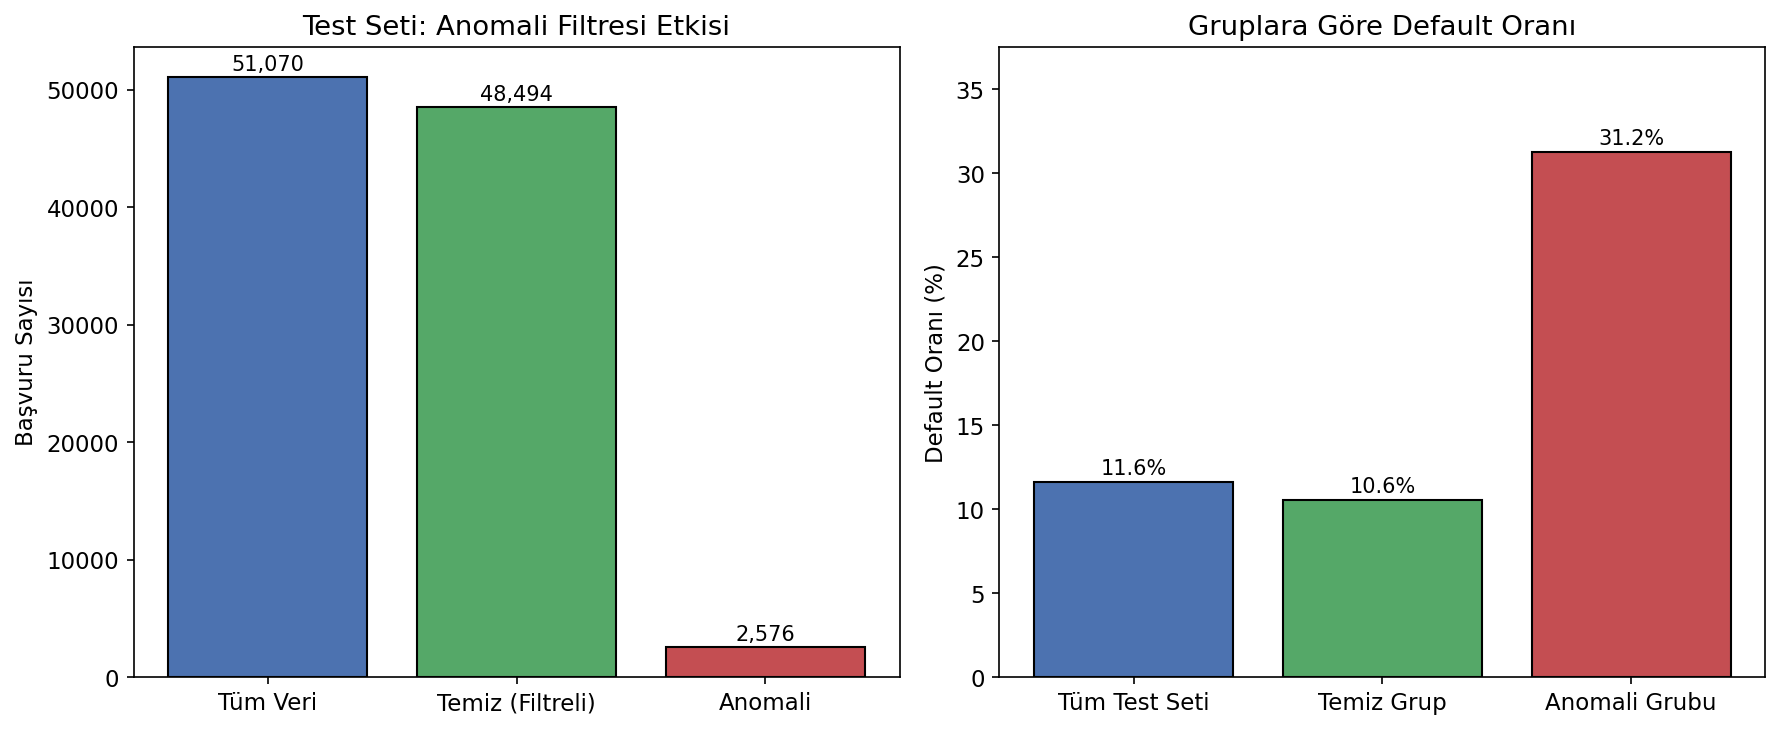

Kaydedildi: if_03_pipeline_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sol: Test seti dağılımı
bars = axes[0].bar(['Tüm Veri', 'Temiz (Filtreli)', 'Anomali'],
                   [n_total, n_clean, n_anomaly],
                   color=['#4C72B0', '#55A868', '#C44E52'],
                   edgecolor='black')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Test Seti: Anomali Filtresi Etkisi')
axes[0].set_ylabel('Başvuru Sayısı')

# Sağ: Default oranı karşılaştırması
categories = ['Tüm Test Seti', 'Temiz Grup', 'Anomali Grubu']
rates = [y_test.mean()*100, default_rate_clean*100, default_rate_anomaly*100]
colors = ['#4C72B0', '#55A868', '#C44E52']
bars2 = axes[1].bar(categories, rates, color=colors, edgecolor='black')
for bar, rate in zip(bars2, rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Gruplara Göre Default Oranı')
axes[1].set_ylabel('Default Oranı (%)')
axes[1].set_ylim(0, max(rates) * 1.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'if_03_pipeline_comparison.png')
plt.show()
print('Kaydedildi: if_03_pipeline_comparison.png')

## 7. Model ve Metadata Kaydet

In [11]:
joblib.dump(iso, MODEL_DIR / 'isolation_forest.joblib', compress=3)
print('Model kaydedildi: isolation_forest.joblib')

Model kaydedildi: isolation_forest.joblib


In [12]:
metadata = {
    "model_version": "1.0.0",
    "trained_at": datetime.now().isoformat(),
    "params": params,
    "anomaly_threshold": float(threshold_val),
    "n_features": X_train.shape[1],
    "train_samples": len(X_train),
    "train_anomaly_count": int(train_anomaly.sum()),
    "train_anomaly_rate": float(train_anomaly.mean())
}

with open(MODEL_DIR / 'isolation_forest_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print('Metadata kaydedildi: isolation_forest_metadata.json')

Metadata kaydedildi: isolation_forest_metadata.json


## 8. Metrikler

In [13]:
# Pipeline etkisi metrikleri (anomali filtresi kaç default yakaladı)
tp = int(((test_anomaly == 1) & (y_test == 1)).sum())  # Anomali & Default
fp = int(((test_anomaly == 1) & (y_test == 0)).sum())  # Anomali & Ödendi
tn = int(((test_anomaly == 0) & (y_test == 0)).sum())  # Normal & Ödendi
fn = int(((test_anomaly == 0) & (y_test == 1)).sum())  # Normal & Default

total_defaults = int(y_test.sum())
precision_if = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_if    = tp / total_defaults if total_defaults > 0 else 0

metrics = {
    "test_samples": n_total,
    "test_anomaly_count": int(n_anomaly),
    "test_anomaly_rate": float(test_anomaly.mean()),
    "default_rate_clean_group": float(default_rate_clean),
    "default_rate_anomaly_group": float(default_rate_anomaly),
    "anomaly_precision_as_default_detector": float(precision_if),
    "anomaly_recall_as_default_detector": float(recall_if),
    "confusion": {"tp": tp, "fp": fp, "tn": tn, "fn": fn}
}

with open(METRIC_DIR / 'isolation_forest_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print('Metrikler kaydedildi: isolation_forest_metrics.json')
print(f'\nAnomali grubunda default tespit precision: {precision_if:.3f}')
print(f'Anomali grubunda default tespit recall   : {recall_if:.3f}')
print(f'\nNot: IF doğrudan kredi kararı vermez; sadece aykırı başvuruları işaretler.')

Metrikler kaydedildi: isolation_forest_metrics.json

Anomali grubunda default tespit precision: 0.312
Anomali grubunda default tespit recall   : 0.136

Not: IF doğrudan kredi kararı vermez; sadece aykırı başvuruları işaretler.


## 9. Özet

| Çıktı | Yer |
|---|---|
| `isolation_forest.joblib` | `models/` |
| `isolation_forest_metadata.json` | `models/` |
| `isolation_forest_metrics.json` | `reports/metrics/` |
| `if_01_anomaly_score_distribution.png` | `reports/figures/` |
| `if_02_anomaly_vs_default_overlap.png` | `reports/figures/` |
| `if_03_pipeline_comparison.png` | `reports/figures/` |

**Sonraki adım:** `05_interest_rate_optimization.ipynb` – Stage 3

**Pipeline'a entegrasyon:** `src/pipeline/credit_pipeline.py` → Isolation Forest → XGBoost → Faiz